In [1]:
import os
import warnings
import boto3
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, average_precision_score, brier_score_loss, confusion_matrix, ConfusionMatrixDisplay
from scipy.stats import ks_2samp

#### Functions

In [2]:
# compute evaluation metrics
def compute_metrics(arr_y_true, arr_y_pred):
    flt_auc = roc_auc_score(arr_y_true, arr_y_pred)
    flt_gini = 2 * flt_auc - 1
    flt_ks = ks_2samp(arr_y_pred[arr_y_true == 1], arr_y_pred[arr_y_true == 0]).statistic
    flt_pr_auc = average_precision_score(arr_y_true, arr_y_pred)
    flt_brier = brier_score_loss(arr_y_true, arr_y_pred)
    flt_median_pred = np.median(arr_y_pred)
    flt_mean_pred = np.mean(arr_y_pred)
    flt_target_mean = np.mean(arr_y_true)
    return {'flt_auc': flt_auc, 'flt_gini': flt_gini, 'flt_ks': flt_ks, 'flt_pr_auc': flt_pr_auc, 'flt_brier': flt_brier, 'flt_median_pred': flt_median_pred, 'flt_mean_pred': flt_mean_pred, 'flt_target_mean': flt_target_mean}

In [3]:
# plot roc curves
def plot_roc_curves(dict_splits, str_filename='output/roc_curves.png'):
    fig, ax = plt.subplots(figsize=(8, 6))
    list_colors = ['steelblue', 'salmon', 'seagreen']
    for (str_name, (arr_y_true, arr_y_pred)), str_color in zip(dict_splits.items(), list_colors):
        flt_auc = roc_auc_score(arr_y_true, arr_y_pred)
        arr_fpr, arr_tpr, _ = roc_curve(arr_y_true, arr_y_pred)
        ax.plot(arr_fpr, arr_tpr, color=str_color, linewidth=2, label=f'{str_name} (AUC={flt_auc:.4f})')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
    ax.set_title('ROC Curves', fontsize=16)
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig(str_filename, dpi=300)
    plt.show()

In [4]:
# plot precision recall curves
def plot_precision_recall_curves(dict_splits, str_filename='output/precision_recall_curves.png'):
    fig, ax = plt.subplots(figsize=(8, 6))
    list_colors = ['steelblue', 'salmon', 'seagreen']
    for (str_name, (arr_y_true, arr_y_pred)), str_color in zip(dict_splits.items(), list_colors):
        flt_pr_auc = average_precision_score(arr_y_true, arr_y_pred)
        arr_precision, arr_recall, _ = precision_recall_curve(arr_y_true, arr_y_pred)
        ax.plot(arr_recall, arr_precision, color=str_color, linewidth=2, label=f'{str_name} (PR AUC={flt_pr_auc:.4f})')
    ax.set_title('Precision-Recall Curves', fontsize=16)
    ax.set_xlabel('Recall', fontsize=12)
    ax.set_ylabel('Precision', fontsize=12)
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig(str_filename, dpi=300)
    plt.show()

In [5]:
# plot calibration
def plot_calibration(dict_splits, int_n_bins=10, str_filename='output/calibration.png'):
    fig, ax = plt.subplots(figsize=(8, 6))
    list_colors = ['steelblue', 'salmon', 'seagreen']
    for (str_name, (arr_y_true, arr_y_pred)), str_color in zip(dict_splits.items(), list_colors):
        flt_brier = brier_score_loss(arr_y_true, arr_y_pred)
        arr_bins = np.linspace(0, 1, int_n_bins + 1)
        arr_bin_indices = np.digitize(arr_y_pred, arr_bins) - 1
        arr_bin_indices = np.clip(arr_bin_indices, 0, int_n_bins - 1)
        list_predicted = []
        list_actual = []
        for i in range(int_n_bins):
            arr_mask = arr_bin_indices == i
            if arr_mask.sum() > 0:
                list_predicted.append(arr_y_pred[arr_mask].mean())
                list_actual.append(arr_y_true[arr_mask].mean())
        ax.plot(list_predicted, list_actual, marker='o', color=str_color, linewidth=2, label=f'{str_name} (Brier={flt_brier:.4f})')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
    ax.set_title('Calibration Plot', fontsize=16)
    ax.set_xlabel('Mean Predicted Probability', fontsize=12)
    ax.set_ylabel('Actual Default Rate', fontsize=12)
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig(str_filename, dpi=300)
    plt.show()

In [6]:
# plot kde of predictions
def plot_kde_predictions(dict_splits, str_filename='output/kde_predictions.png'):
    warnings.filterwarnings('ignore')
    fig, ax = plt.subplots(figsize=(10, 5))
    list_colors = ['steelblue', 'salmon', 'seagreen']
    for (str_name, (arr_y_true, arr_y_pred)), str_color in zip(dict_splits.items(), list_colors):
        flt_median = np.median(arr_y_pred)
        sns.kdeplot(arr_y_pred, ax=ax, color=str_color, linewidth=2, label=f'{str_name} (Median={flt_median:.4f})', fill=True, alpha=0.2)
    ax.set_title('KDE of Predictions', fontsize=16)
    ax.set_xlabel('Predicted Probability', fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig(str_filename, dpi=300)
    plt.show()
    warnings.filterwarnings('default')

In [7]:
# plot confusion matrix
def plot_confusion_matrix(arr_y_true, arr_y_pred, flt_threshold=0.5, str_filename='output/confusion_matrix.png'):
    arr_y_class = (arr_y_pred >= flt_threshold).astype(int)
    arr_cm = confusion_matrix(arr_y_true, arr_y_class)
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(arr_cm, display_labels=['No Default', 'Default']).plot(ax=ax, cmap='Blues')
    ax.set_title(f'Confusion Matrix (Threshold={flt_threshold})', fontsize=16)
    plt.tight_layout()
    plt.savefig(str_filename, dpi=300)
    plt.show()

In [8]:
# plot shap partial dependence plots
def plot_shap_pdp(model, arr_X, list_feature_cols, str_filename='output/shap_pdp.png'):
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(arr_X)
    int_n_features = len(list_feature_cols)
    int_n_cols = 3
    int_n_rows = int(np.ceil(int_n_features / int_n_cols))
    fig, axes = plt.subplots(int_n_rows, int_n_cols, figsize=(6 * int_n_cols, 4 * int_n_rows))
    axes = axes.flatten()
    for i, str_col in enumerate(list_feature_cols):
        ax = axes[i]
        ax.scatter(arr_X[:, i], shap_values[:, i], alpha=0.3, s=5, color='steelblue')
        ax.set_title(str_col, fontsize=12)
        ax.set_xlabel('Feature Value', fontsize=10)
        ax.set_ylabel('SHAP Value', fontsize=10)
        ax.axhline(y=0, color='black', linewidth=0.5)
    # hide unused axes
    for j in range(int_n_features, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle('SHAP Partial Dependence Plots', fontsize=16, y=1.01)
    plt.tight_layout()
    plt.savefig(str_filename, dpi=300, bbox_inches='tight')
    plt.show()

In [9]:
# plot decile analysis
def plot_decile_analysis(arr_y_true, arr_y_pred, str_filename='output/decile_analysis.png'):
    warnings.filterwarnings('ignore')
    # create dataframe for binning
    df_decile = pd.DataFrame({'y_true': arr_y_true, 'y_pred': arr_y_pred})
    # qcut assigns 0=lowest PD, 9=highest PD; invert so decile 1=highest risk
    df_decile['decile'] = 10 - pd.qcut(df_decile['y_pred'], 10, labels=False, duplicates='drop')
    # compute stats per decile
    list_rows = []
    for int_d in sorted(df_decile['decile'].unique()):
        df_sub = df_decile[df_decile['decile'] == int_d]
        flt_min_pred = df_sub['y_pred'].min()
        flt_max_pred = df_sub['y_pred'].max()
        int_count = len(df_sub)
        flt_actual_rate = df_sub['y_true'].mean()
        list_rows.append({
            'int_decile': int_d,
            'str_pd_range': f'{flt_min_pred:.3f}-{flt_max_pred:.3f}',
            'int_count': int_count,
            'flt_actual_default_rate': flt_actual_rate,
        })
    df_stats = pd.DataFrame(list_rows)
    # cumulative capture rate: top N deciles capture what % of all defaults
    # decile 1 = highest risk, so cumulate from decile 1 downward
    int_total_defaults = int(arr_y_true.sum())
    list_capture = []
    int_cum_defaults = 0
    for int_d in sorted(df_decile['decile'].unique()):
        int_cum_defaults += int(df_decile[df_decile['decile'] == int_d]['y_true'].sum())
        flt_capture = int_cum_defaults / int_total_defaults if int_total_defaults > 0 else 0.0
        list_capture.append(flt_capture)
    df_stats['flt_cumulative_capture_rate'] = list_capture
    # display table
    print(df_stats.to_string(index=False))
    # plot
    fig, ax = plt.subplots(figsize=(10, 6))
    arr_x = np.arange(len(df_stats))
    ax.bar(arr_x, df_stats['flt_actual_default_rate'], color='steelblue', edgecolor='black')
    # annotate bars
    for i, flt_rate in enumerate(df_stats['flt_actual_default_rate']):
        ax.text(i, flt_rate + 0.005, f'{flt_rate:.3f}', ha='center', va='bottom', fontsize=9)
    ax.set_xticks(arr_x)
    ax.set_xticklabels(df_stats['str_pd_range'], rotation=45, ha='right', fontsize=8)
    ax.set_title('Actual Default Rate by Predicted PD Decile', fontsize=16)
    ax.set_xlabel('Predicted PD Range (Decile)', fontsize=12)
    ax.set_ylabel('Actual Default Rate', fontsize=12)
    ax.set_ylim(top=ax.get_ylim()[1] * 1.15)
    plt.tight_layout()
    plt.savefig(str_filename, dpi=300)
    plt.show()
    warnings.filterwarnings('default')

In [10]:
# plot threshold sensitivity analysis
def plot_threshold_analysis(arr_y_true, arr_y_pred, str_filename='output/threshold_analysis.png'):
    from sklearn.metrics import precision_score, recall_score, f1_score
    list_thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.50]
    list_rows = []
    for flt_thresh in list_thresholds:
        arr_y_class = (arr_y_pred >= flt_thresh).astype(int)
        flt_precision = precision_score(arr_y_true, arr_y_class, zero_division=0)
        flt_recall = recall_score(arr_y_true, arr_y_class, zero_division=0)
        flt_f1 = f1_score(arr_y_true, arr_y_class, zero_division=0)
        flt_approval_rate = (arr_y_pred < flt_thresh).mean()
        list_rows.append({
            'flt_threshold': flt_thresh,
            'flt_precision': flt_precision,
            'flt_recall': flt_recall,
            'flt_f1': flt_f1,
            'flt_approval_rate': flt_approval_rate,
        })
    df_thresh = pd.DataFrame(list_rows)
    # display table
    print(df_thresh.to_string(index=False))
    # plot
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(df_thresh['flt_threshold'], df_thresh['flt_precision'], marker='o', color='steelblue', linewidth=2, label='Precision')
    ax.plot(df_thresh['flt_threshold'], df_thresh['flt_recall'], marker='s', color='salmon', linewidth=2, label='Recall')
    ax.plot(df_thresh['flt_threshold'], df_thresh['flt_f1'], marker='^', color='seagreen', linewidth=2, label='F1')
    ax.plot(df_thresh['flt_threshold'], df_thresh['flt_approval_rate'], marker='D', color='gray', linewidth=2, linestyle='--', label='Approval Rate')
    ax.set_title('Threshold Sensitivity Analysis', fontsize=16)
    ax.set_xlabel('Threshold', fontsize=12)
    ax.set_ylabel('Score / Rate', fontsize=12)
    ax.legend(loc='lower right')
    ax.set_xticks(list_thresholds)
    plt.tight_layout()
    plt.savefig(str_filename, dpi=300)
    plt.show()

In [11]:
# generate adverse action reason codes
def generate_reason_codes(model, arr_X, list_feature_cols, int_top_n=4, str_filename='output/reason_codes_sample.png'):
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(arr_X)
    
    # map feature names to consumer-facing reason descriptions
    dict_reason_map = {
        'bureau_score': 'Credit score is too low',
        'utilization': 'Credit utilization is too high',
        'delinq_12m': 'Too many recent delinquencies',
        'inquiries_6m': 'Too many recent credit inquiries',
        'public_records': 'Adverse public records on file',
        'employment_length_years': 'Insufficient length of employment',
        'stated_income': 'Insufficient income',
        'loan_amount': 'Loan amount is too high',
        'term_months': 'Loan term is too long',
        'open_trades': 'Number of open trade lines',
        'has_prior_loans_with_us': 'Prior loan history',
        'channel': 'Application channel',
    }
    
    # for each observation, get the top N features pushing prediction higher (toward default)
    list_reasons = []
    for i in range(len(arr_X)):
        arr_shap_i = shap_values[i]
        # sort by SHAP value descending (positive SHAP = pushes toward default)
        list_indices = np.argsort(arr_shap_i)[::-1][:int_top_n]
        list_top_reasons = []
        for idx in list_indices:
            if arr_shap_i[idx] > 0:  # only include features pushing toward default
                str_feature = list_feature_cols[idx]
                str_reason = dict_reason_map.get(str_feature, str_feature)
                list_top_reasons.append(str_reason)
        list_reasons.append(list_top_reasons)
    
    # show sample of reason codes for highest-risk applicants
    arr_preds = model.predict_proba(arr_X)[:, 1]
    list_top_risk_indices = np.argsort(arr_preds)[::-1][:10]
    
    list_rows = []
    for idx in list_top_risk_indices:
        list_rows.append({
            'int_index': idx,
            'flt_predicted_pd': arr_preds[idx],
            'str_reason_1': list_reasons[idx][0] if len(list_reasons[idx]) > 0 else '',
            'str_reason_2': list_reasons[idx][1] if len(list_reasons[idx]) > 1 else '',
            'str_reason_3': list_reasons[idx][2] if len(list_reasons[idx]) > 2 else '',
            'str_reason_4': list_reasons[idx][3] if len(list_reasons[idx]) > 3 else '',
        })
    
    df_reasons = pd.DataFrame(list_rows)
    print('Adverse Action Reason Codes (Top 10 Highest-Risk Applicants):')
    display(df_reasons)
    
    # plot frequency of each reason across all applicants
    from collections import Counter
    counter = Counter()
    for reasons in list_reasons:
        for reason in reasons:
            counter[reason] += 1
    
    df_freq = pd.DataFrame(counter.most_common(), columns=['str_reason', 'int_count'])
    df_freq['flt_pct'] = df_freq['int_count'] / len(arr_X) * 100
    
    fig, ax = plt.subplots(figsize=(10, max(5, len(df_freq) * 0.5)))
    ax.barh(range(len(df_freq)), df_freq['flt_pct'], color='steelblue', edgecolor='black')
    ax.set_yticks(range(len(df_freq)))
    ax.set_yticklabels(df_freq['str_reason'])
    ax.set_title('Frequency of Adverse Action Reasons (% of Applicants)', fontsize=16)
    ax.set_xlabel('% of Applicants', fontsize=12)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(str_filename, dpi=300)
    plt.show()
    
    return list_reasons

#### Constants

In [12]:
# bucket
str_bucket = os.getcwd().split('/')[4].replace('_', '-')
print(f'Bucket: {str_bucket}')

# step
str_step = os.getcwd().split('/')[-1]
print(f'Step: {str_step}')

# s3 input path
str_s3_input = f's3://{str_bucket}/03_preprocessing'
print(f'S3 Input: {str_s3_input}')

# target
str_target = 'default_12m'
print(f'Target: {str_target}')

# model and feature columns
str_model_path = '../04_model/output/xgboost_model.joblib'
str_feature_cols_path = '../04_model/output/feature_cols.joblib'

# output directory
os.makedirs('output', exist_ok=True)

Bucket: credit-risk-claude
Step: 05_model_eval
S3 Input: s3://credit-risk-claude/03_preprocessing
Target: default_12m


#### Read Data and Model

In [13]:
# read preprocessed data
df_train = pd.read_parquet(f'{str_s3_input}/df_train_clean.parquet')
df_valid = pd.read_parquet(f'{str_s3_input}/df_valid_clean.parquet')
df_test = pd.read_parquet(f'{str_s3_input}/df_test_clean.parquet')

# combine train and valid (model was trained on combined train+valid)
df_train_valid = pd.concat([df_train, df_valid], ignore_index=True)

# load model and feature columns
model = joblib.load(str_model_path)
list_feature_cols = joblib.load(str_feature_cols_path)

print(f'Train+Valid: {df_train_valid.shape}')
print(f'Test: {df_test.shape}')
print(f'Features: {len(list_feature_cols)}')

Train+Valid: (21511, 20)
Test: (3797, 20)
Features: 12


/home/ec2-user/anaconda3/envs/tensorflow2_p310/lib/python3.12/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


#### Generate Predictions

In [14]:
# generate predictions
arr_y_train_valid = df_train_valid[str_target].values
arr_y_test = df_test[str_target].values

arr_pred_train_valid = model.predict_proba(df_train_valid[list_feature_cols].values)[:, 1]
arr_pred_test = model.predict_proba(df_test[list_feature_cols].values)[:, 1]

# dict for passing to plot functions
dict_splits = {
    'Train+Valid': (arr_y_train_valid, arr_pred_train_valid),
    'Test': (arr_y_test, arr_pred_test),
}

#### Metrics Summary

AUC, Gini (2*AUC-1), and KS statistic for Train+Valid (in-sample) and Test (out-of-time holdout). The model was trained on combined train+valid data, so Train+Valid metrics reflect in-sample performance while Test is the true out-of-time evaluation. Gini is the standard discrimination metric in credit risk. KS measures the maximum separation between the cumulative distributions of defaulters and non-defaulters.

In [15]:
# compute metrics for each split
list_rows = []
for str_name, (arr_y_true, arr_y_pred) in dict_splits.items():
    dict_metrics = compute_metrics(arr_y_true, arr_y_pred)
    dict_metrics['str_split'] = str_name
    list_rows.append(dict_metrics)

df_metrics = pd.DataFrame(list_rows)[['str_split', 'flt_auc', 'flt_gini', 'flt_ks', 'flt_pr_auc', 'flt_brier', 'flt_median_pred', 'flt_mean_pred', 'flt_target_mean']]
df_metrics.to_csv('output/metrics_summary.csv', index=False)
df_metrics

,str_split,flt_auc,flt_gini,flt_ks,flt_pr_auc,flt_brier,flt_median_pred,flt_mean_pred,flt_target_mean
0,Train+Valid,0.813613,0.627226,0.468537,0.532018,0.118234,0.126667,0.187593,0.187578
1,Test,0.803229,0.606458,0.477883,0.484557,0.119567,0.130033,0.186540,0.182513


#### ROC Curves

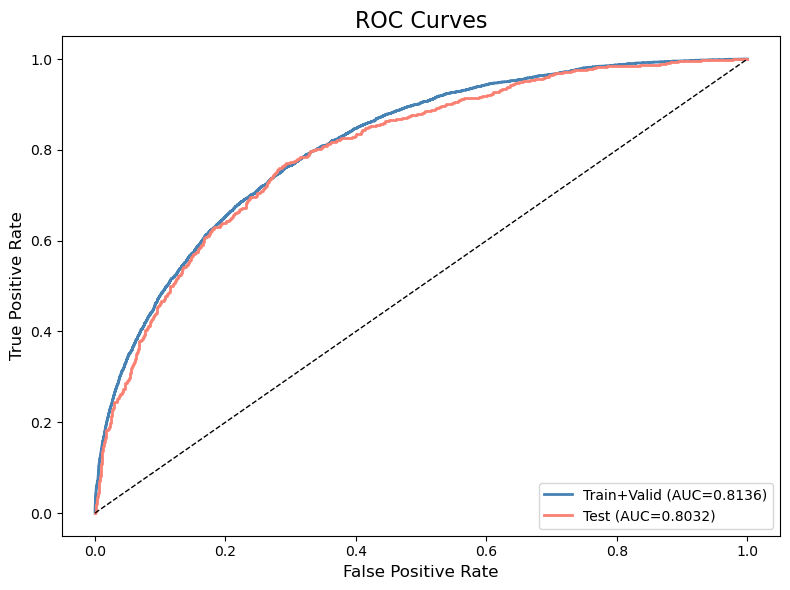

In [16]:
plot_roc_curves(dict_splits)

#### Precision-Recall Curves

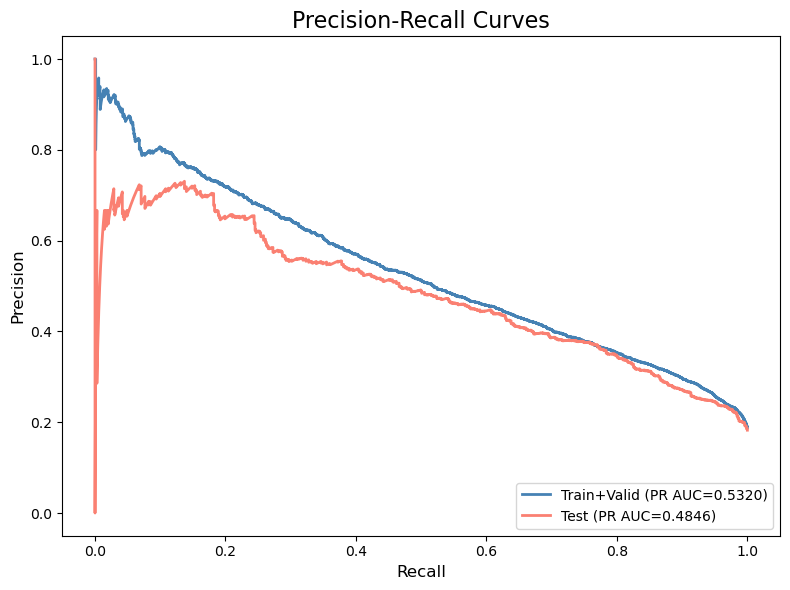

In [17]:
plot_precision_recall_curves(dict_splits)

#### Calibration

Calibration measures how well the predicted probabilities match actual default rates. A well-calibrated model's points will fall close to the diagonal. This is critical for credit risk because predicted probabilities are used directly for pricing and capital allocation.

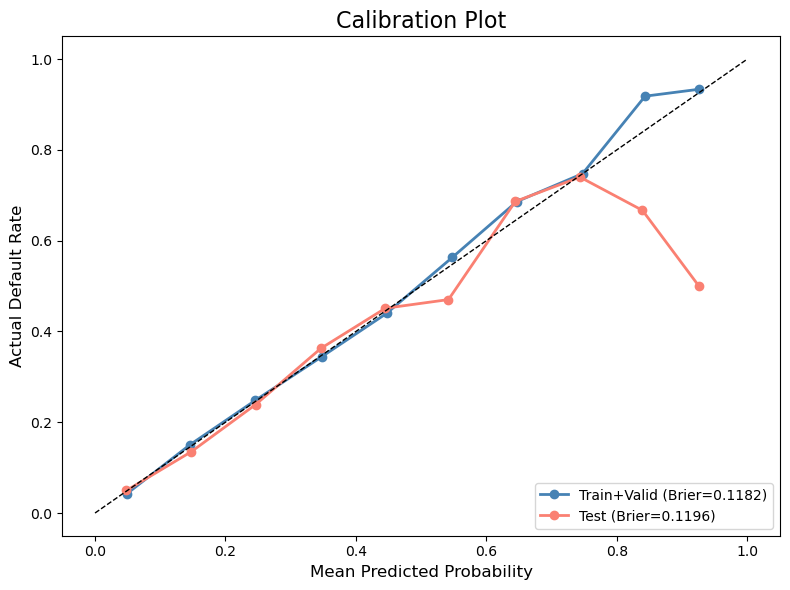

In [18]:
plot_calibration(dict_splits)

#### KDE of Predictions

KDE plots show the distribution of predicted probabilities across splits. Similar distributions indicate stable model behavior. Divergence between Train+Valid and Test may indicate overfitting or data drift.

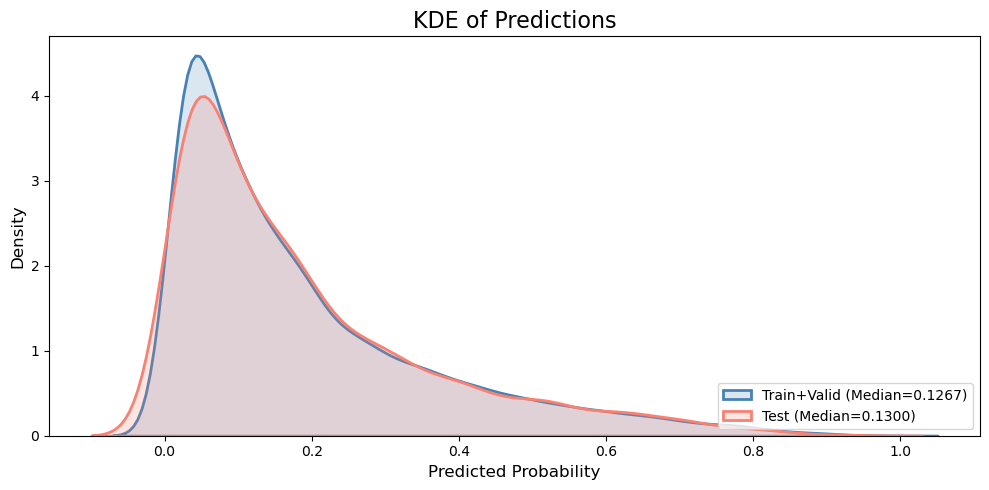

In [19]:
plot_kde_predictions(dict_splits)

#### Confusion Matrix (Test Set)

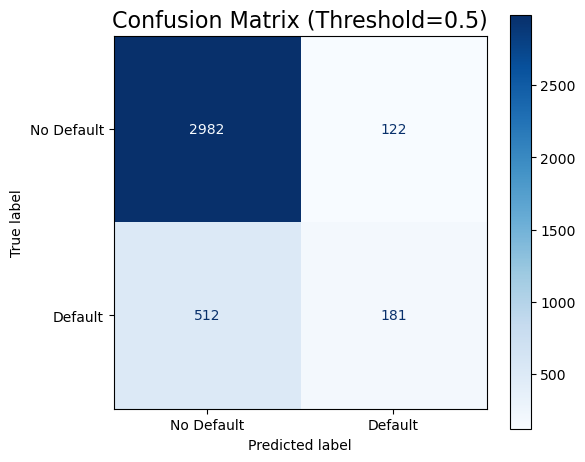

In [20]:
plot_confusion_matrix(arr_y_test, arr_pred_test)

#### SHAP Partial Dependence Plots

SHAP partial dependence plots show the relationship between each feature's value and its SHAP contribution to the prediction. These are useful for verifying that monotone constraints are being respected and for understanding the nonlinear relationships the model has learned.

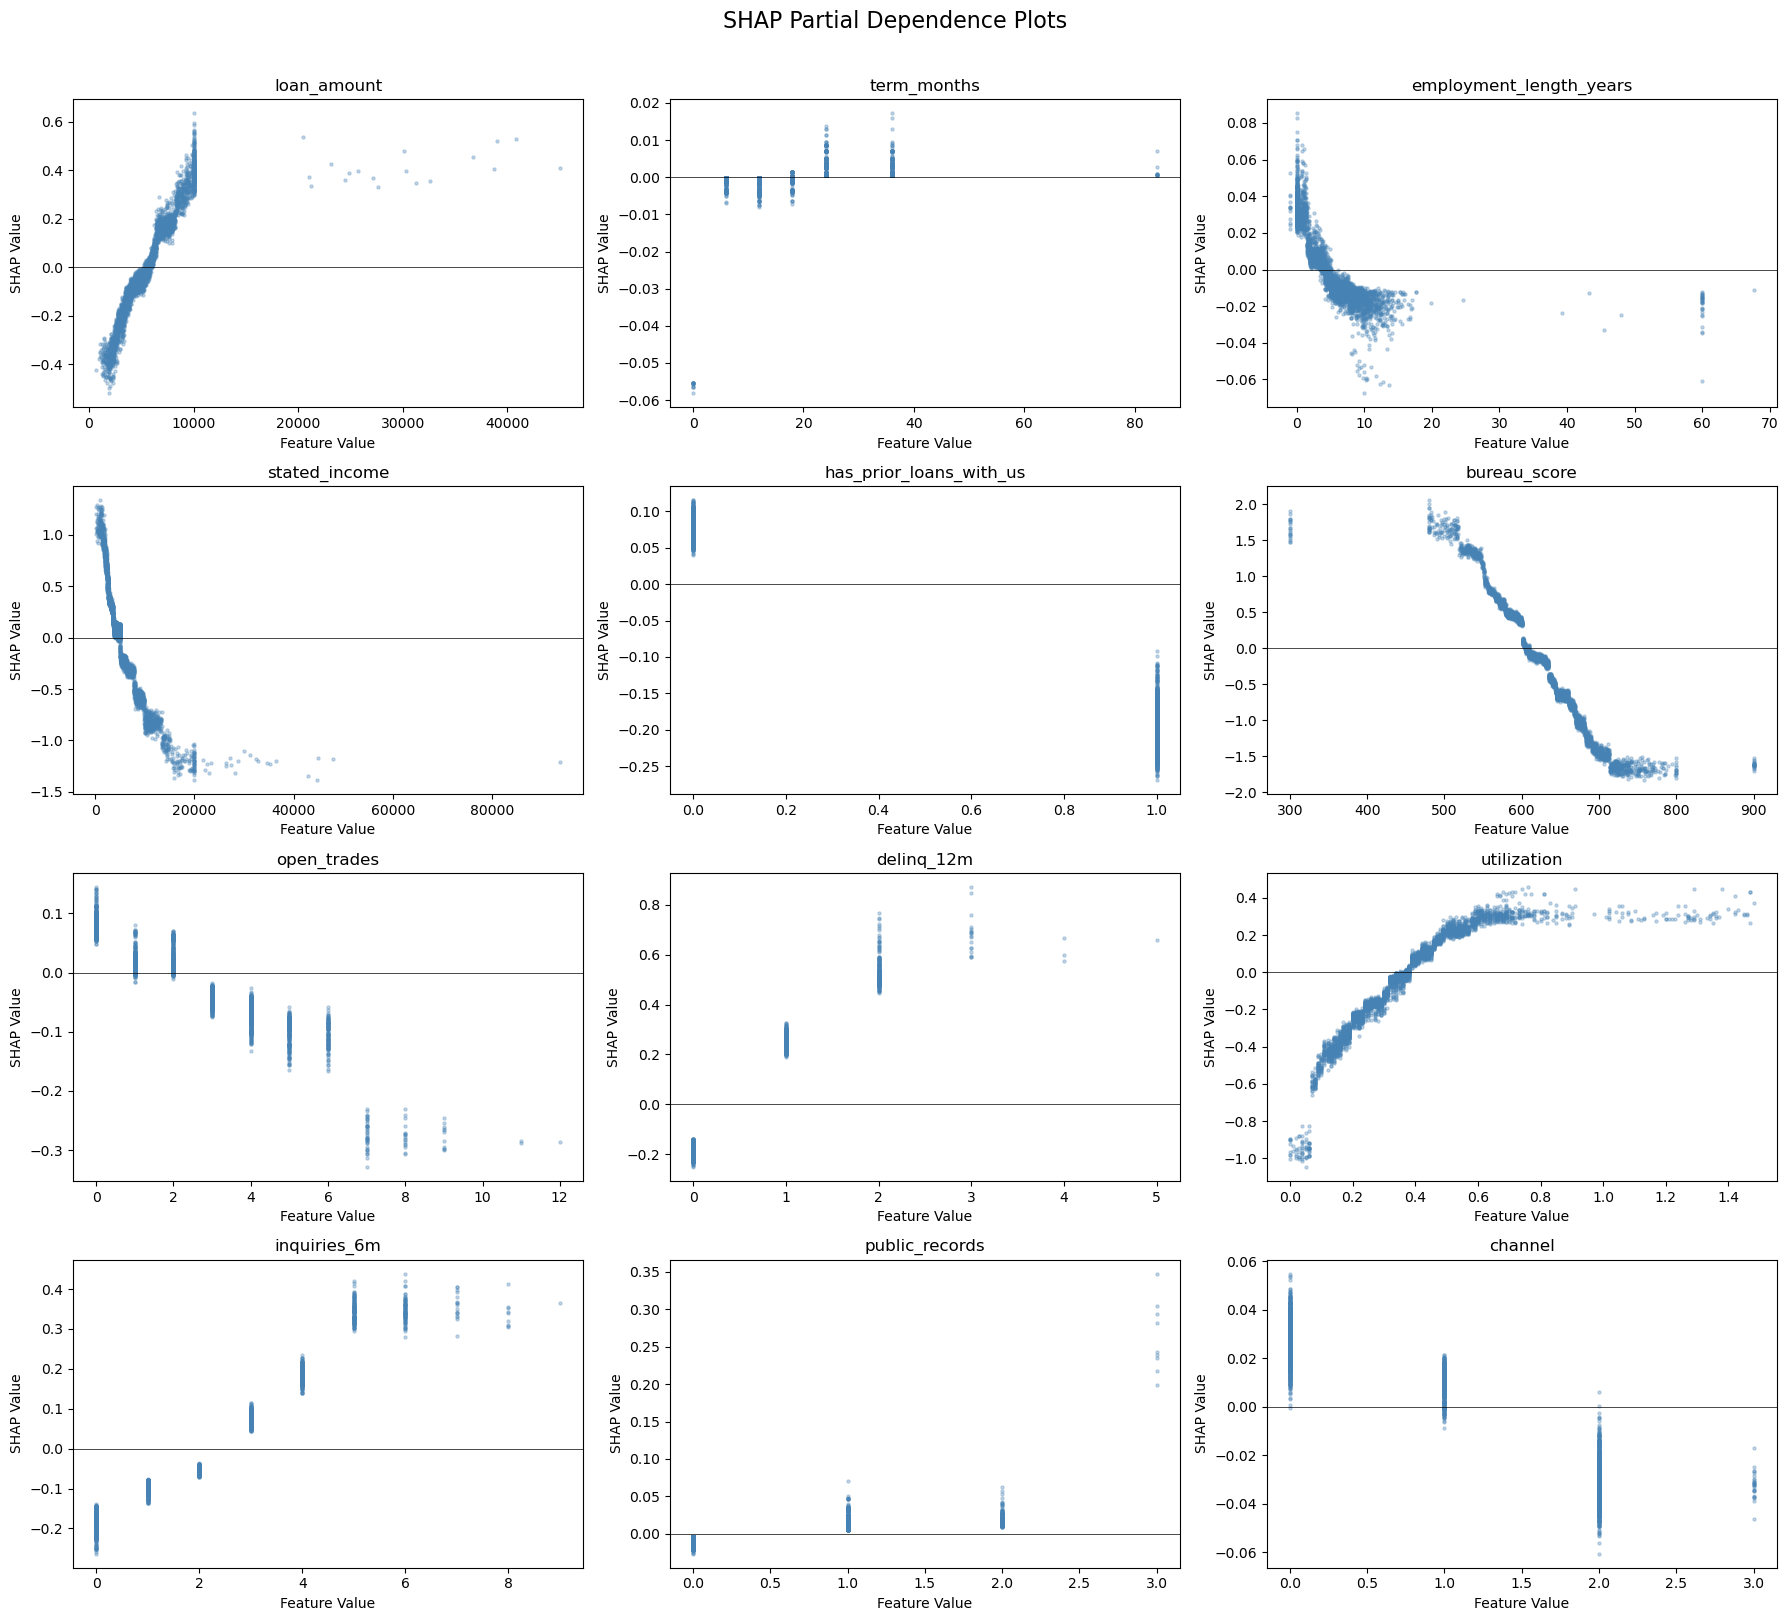

In [21]:
plot_shap_pdp(model, df_test[list_feature_cols].values, list_feature_cols)

#### Decile Analysis

Decile analysis is standard in credit risk for evaluating rank-ordering within score bands. Predictions are binned into 10 equal-sized groups, and the actual default rate is compared across deciles. A well-discriminating model will show monotonically increasing default rates from the lowest to the highest decile.

 int_decile str_pd_range  int_count  flt_actual_default_rate  flt_cumulative_capture_rate
          1  0.452-0.929        380                 0.557895                     0.305916
          2  0.309-0.451        380                 0.394737                     0.522367
          3  0.221-0.308        379                 0.258575                     0.663781
          4  0.169-0.221        380                 0.218421                     0.783550
          5  0.130-0.169        379                 0.124011                     0.851371
          6  0.092-0.130        380                 0.081579                     0.896104
          7  0.066-0.092        380                 0.092105                     0.946609
          8  0.043-0.066        379                 0.058047                     0.978355
          9  0.025-0.043        380                 0.023684                     0.991342
         10  0.002-0.025        380                 0.015789                     1.000000


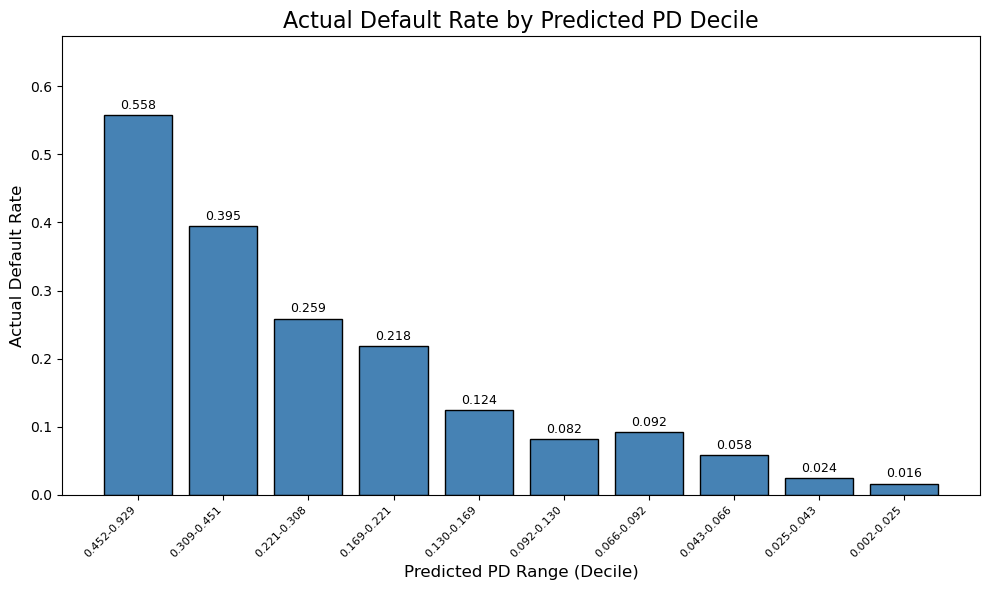

In [22]:
plot_decile_analysis(arr_y_test, arr_pred_test)

#### Threshold Sensitivity Analysis

The optimal classification cutoff depends on the cost of false positives versus false negatives and varies by business use case. A lower threshold catches more defaults (higher recall) but declines more applicants (lower approval rate). This analysis shows precision, recall, F1, and approval rate across a range of thresholds to support business decision-making.

 flt_threshold  flt_precision  flt_recall   flt_f1  flt_approval_rate
          0.10       0.280037    0.884560 0.425399           0.423492
          0.15       0.333923    0.816739 0.474037           0.553595
          0.20       0.385039    0.705628 0.498217           0.665525
          0.25       0.431683    0.629149 0.512038           0.734001
          0.30       0.472888    0.541126 0.504711           0.791151
          0.50       0.597360    0.261183 0.363454           0.920200


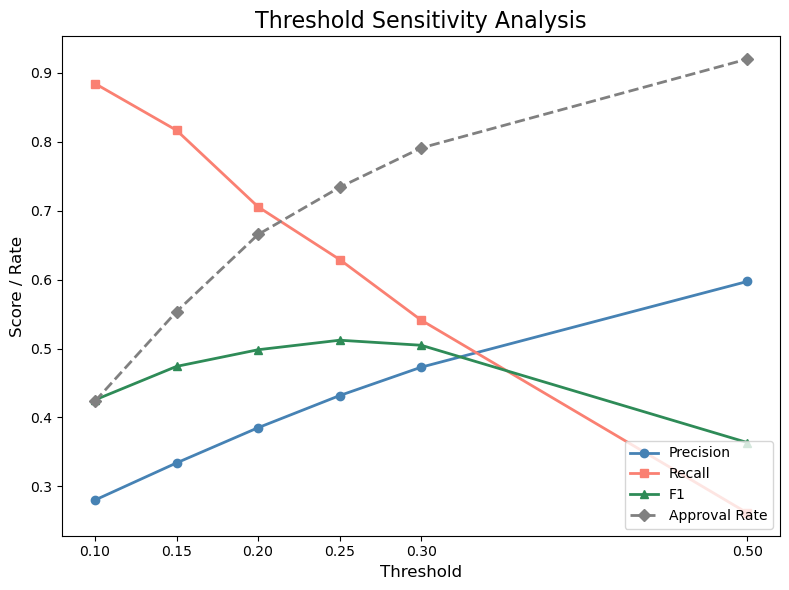

In [23]:
plot_threshold_analysis(arr_y_test, arr_pred_test)

#### Adverse Action Reason Codes

Under ECOA and CFPB guidance, lenders must provide specific, accurate reasons when taking adverse action on a credit application. SHAP values identify the top features pushing each applicant's prediction toward default, which are then mapped to consumer-facing reason descriptions. The top 4 reasons are generated per applicant.

Adverse Action Reason Codes (Top 10 Highest-Risk Applicants):


,int_index,flt_predicted_pd,str_reason_1,str_reason_2,str_reason_3,str_reason_4
0,3732,0.928525,Credit score is too low,Too many recent delinquencies,Credit utilization is too high,Loan amount is too high
1,1206,0.922779,Credit score is too low,Too many recent delinquencies,Insufficient income,Too many recent credit inquiries
2,320,0.893621,Credit score is too low,Insufficient income,Credit utilization is too high,Too many recent delinquencies
3,2614,0.891510,Credit score is too low,Insufficient income,Too many recent credit inquiries,Too many recent delinquencies
4,1143,0.861348,Credit score is too low,Too many recent delinquencies,Loan amount is too high,Number of open trade lines
5,3550,0.852353,Credit score is too low,Too many recent delinquencies,Too many recent credit inquiries,Insufficient income
6,331,0.836541,Credit score is too low,Insufficient income,Too many recent credit inquiries,Credit utilization is too high
7,1613,0.834783,Insufficient income,Credit score is too low,Loan amount is too high,Too many recent credit inquiries
8,657,0.831415,Credit score is too low,Insufficient income,Too many recent delinquencies,Loan amount is too high
9,2162,0.828976,Credit score is too low,Credit utilization is too high,Too many recent credit inquiries,Insufficient income


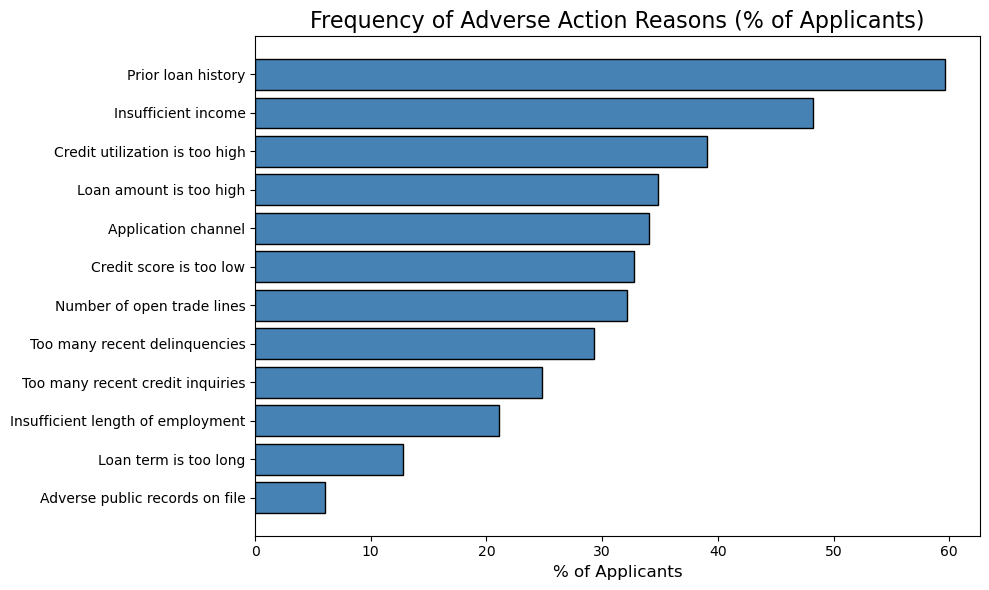

In [24]:
list_reason_codes = generate_reason_codes(model, df_test[list_feature_cols].values, list_feature_cols)